In [15]:
import numpy as np
import matplotlib.pyplot as plt


- Квадратрисса Динострата
- (IV) тип граничных условий

In [16]:
def X(t): 
    res = []
    for _t in t:
        if np.sin(np.pi * (1 - _t) / 2):
            res.append((1 - _t) / np.tan(np.pi * (1 - _t) / 2))
        else:
            res.append(2 / np.pi)

    return np.array(res)


def Y(t):
    return 1 - t

[]

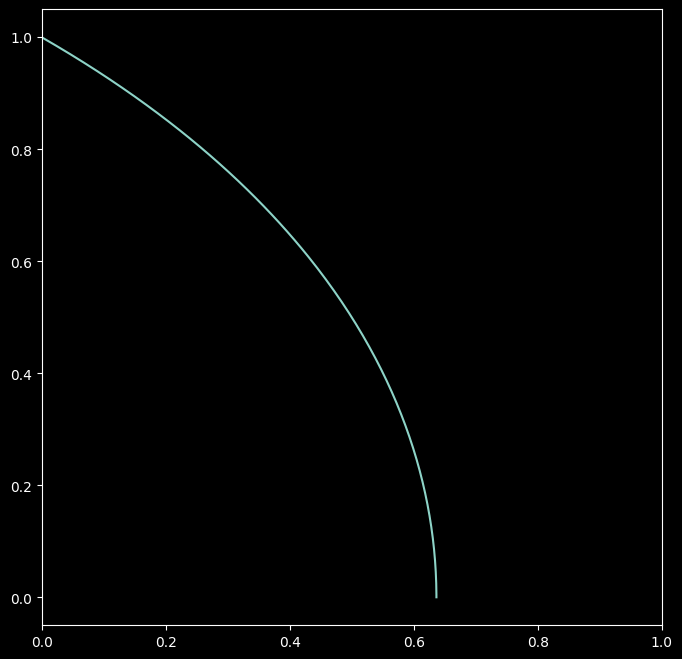

In [17]:
t = np.linspace(0, 1, 200)

plt.figure(figsize=(8, 8))

plt.plot(X(t), Y(t))

plt.xlim(0, 1)

plt.plot()

In [18]:
def build_spline_moments(x, y, p, q):
    """
    Построение моментов для рационального сплайна
    p, q - массивы длины n (количество интервалов)
    """
    n = len(x) - 1  # количество интервалов
    h = x[1] - x[0]  # предполагаем равномерную сетку
    
    # Функции для вычисления коэффициентов
    def _P(p_val, q_val):
        return (3 + 3 * p_val + p_val**2) / ((2 + q_val) * (2 + p_val) - 1)
    
    def _Q(p_val, q_val):
        return (3 + 3 * q_val + q_val**2) / ((2 + q_val) * (2 + p_val) - 1)
    
    # Инициализация матрицы и правой части
    A = np.zeros((n + 1, n + 1))
    d = np.zeros(n + 1)
    
    # Внутренние узлы
    for i in range(1, n):
        P = _P(p[i-1], q[i-1])  # для левого интервала
        Q = _Q(p[i], q[i])      # для правого интервала
        
        A[i, i-1] = P / 2
        A[i, i] = P * (2 + q[i-1]) / 2 + Q * (2 + p[i]) / 2
        A[i, i+1] = Q / 2
        
        d[i] = (P * (3 + q[i-1]) * (y[i] - y[i-1]) / (2 * h) + 
                Q * (3 + p[i]) * (y[i+1] - y[i]) / (2 * h))
    
    # Граничные условия (естественные)
    A[0, 0] = 1
    A[0, 1] = 0
    d[0] = 0  # m_0 = 0
    
    A[n, n] = 1  
    A[n, n-1] = 0
    d[n] = 0  # m_n = 0
    
    # Решение системы
    m = np.linalg.solve(A, d)
    return m, h

In [19]:
def spline_eval(x, y, m, p, q, h, x_eval):
    """Вычисление значений сплайна в точках x_eval"""
    n = len(x) - 1
    y_eval = np.zeros_like(x_eval)
    
    for i, x_val in enumerate(x_eval):
        # Находим интервал
        idx = np.searchsorted(x, x_val) - 1
        idx = max(0, min(idx, n-1))
        
        t = (x_val - x[idx]) / h
        
        # Коэффициенты для текущего интервала
        p_i = p[idx]
        q_i = q[idx]
        
        # Вычисление C_i и D_i
        denominator = (2 + q_i) * (2 + p_i) - 1
        
        C_i = (-(3 + q_i) * (y[idx+1] - y[idx]) + 
               h * m[idx] + (2 + q_i) * h * m[idx+1]) / denominator
        
        D_i = ((3 + p_i) * (y[idx+1] - y[idx]) - 
               h * m[idx+1] - (2 + p_i) * h * m[idx]) / denominator
        
        # Вычисление значения сплайна
        rational_term1 = C_i * (t**3 / (1 + p_i * (1 - t)) - t)
        rational_term2 = D_i * ((1-t)**3 / (1 + q_i * t) - (1 - t))
        
        y_eval[i] = (y[idx] * (1 - t) + y[idx+1] * t + 
                     rational_term1 + rational_term2)
    
    return y_eval

In [20]:
def approx(N, p, q):
    t = np.linspace(0, 1, N + 1)
    x = X(t)
    y = Y(t)

    t_dense = np.linspace(0, 1, 200)

    m, h = build_spline_moments(t, x, p, q)

    x_spline = spline_eval(t, x, m, p, q, h, t_dense)

    m, h = build_spline_moments(t, y, p, q)

    y_spline = spline_eval(t, y, m, p, q, h, t_dense)

    print(f'Погрешность = {np.sqrt(((x_spline - X(t_dense)) ** 2 + (y_spline - Y(t_dense)) ** 2).sum())}')

    plt.figure(figsize=(7, 7))
    plt.plot(X(t_dense), Y(t_dense), 'blue', label='Исходная функция', linewidth=2)
    plt.plot(x_spline, y_spline, 'red', linestyle='--', label='Периодический сплайн', linewidth=2)

    plt.xlim(0, 1)

    plt.xlabel('x')
    plt.ylabel('y')

    plt.legend()

    plt.show()

Погрешность = 0.019615618436252195


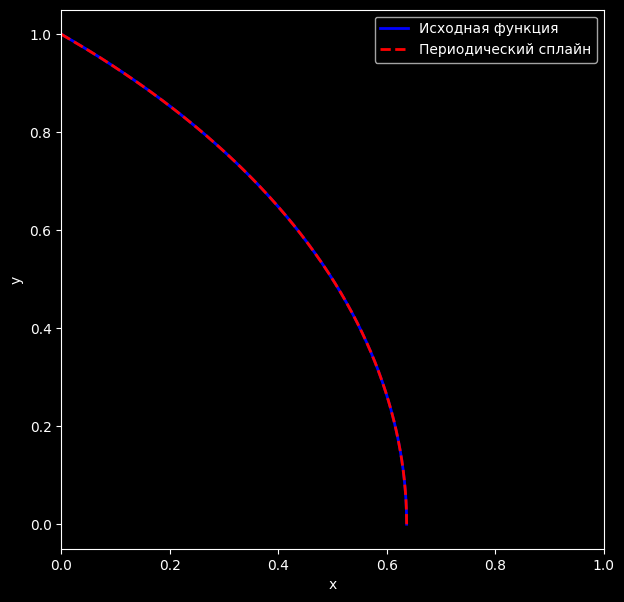

In [21]:
N = 30
p = np.ones(N) * 0.5
q = np.ones(N) * 0.5
approx(N, p, q)